In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [8]:
file_path = ("C:/Users/user/Downloads/titanic.csv")
df = pd.read_csv(file_path)

print('Shape:', df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


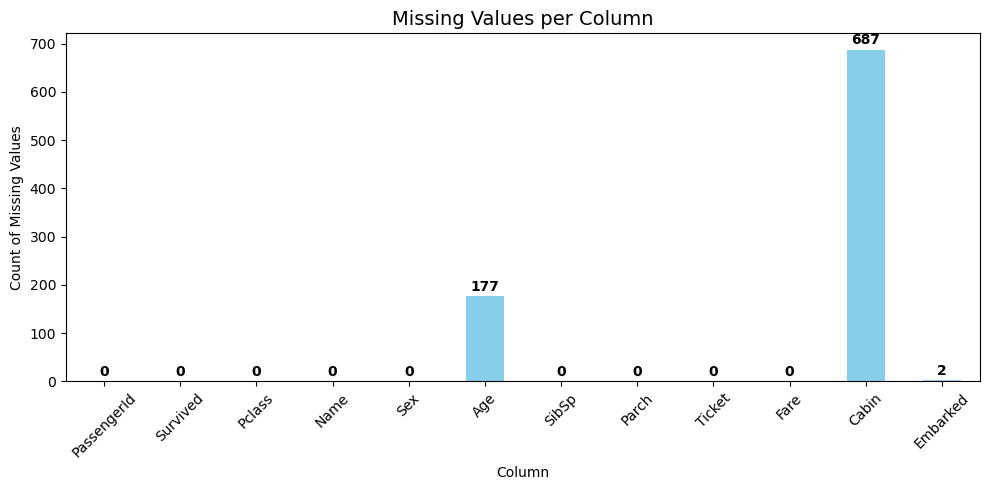

In [12]:
missing = df.isnull().sum()

ax = missing.plot(kind='bar', color='skyblue', figsize=(10, 5))
plt.title('Missing Values per Column', fontsize=14)
plt.ylabel('Count of Missing Values')
plt.xlabel('Column')
plt.xticks(rotation=45)

for index, value in enumerate(missing):
    plt.text(index, value + 5, str(value),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
df = df.drop(columns=['Cabin'])                          # 687 missing — drop
df['Age'] = df['Age'].fillna(df['Age'].median())         # fill with median
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])  # fill with mode

print('Missing values AFTER cleaning:')
print(df.isnull().sum())

Missing values AFTER cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [14]:
print('Duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

Duplicate rows: 0
Shape after removing duplicates: (891, 11)


Survival Counts:
Survived
0    549
1    342
Name: count, dtype: int64


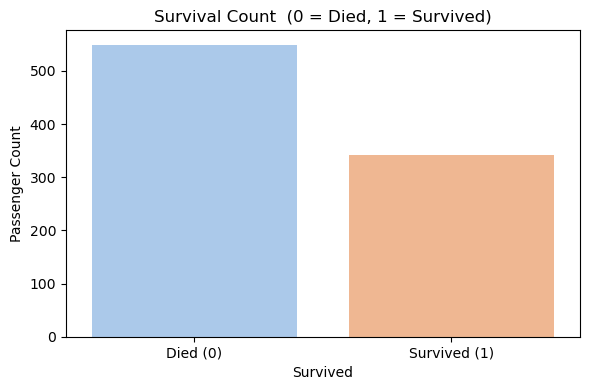

In [15]:
survival_counts = df['Survived'].value_counts()
print('Survival Counts:')
print(survival_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', hue='Survived', data=df, palette='pastel', legend=False)
plt.title('Survival Count  (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Passenger Count')
plt.xticks([0, 1], ['Died (0)', 'Survived (1)'])
plt.tight_layout()
plt.show()

Gender Counts:
Sex
male      577
female    314
Name: count, dtype: int64

Survival by Gender:
Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
dtype: int64


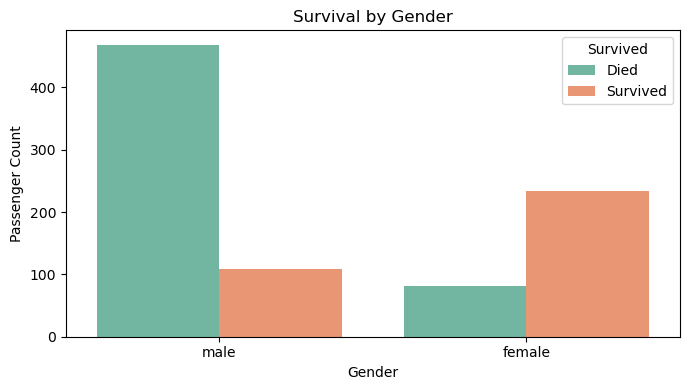

In [16]:
print('Gender Counts:')
print(df['Sex'].value_counts())

print('\nSurvival by Gender:')
print(df.groupby(['Sex', 'Survived']).size())

plt.figure(figsize=(7, 4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.legend(title='Survived', labels=['Died', 'Survived'])
plt.tight_layout()
plt.show()

Passenger Class Counts:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


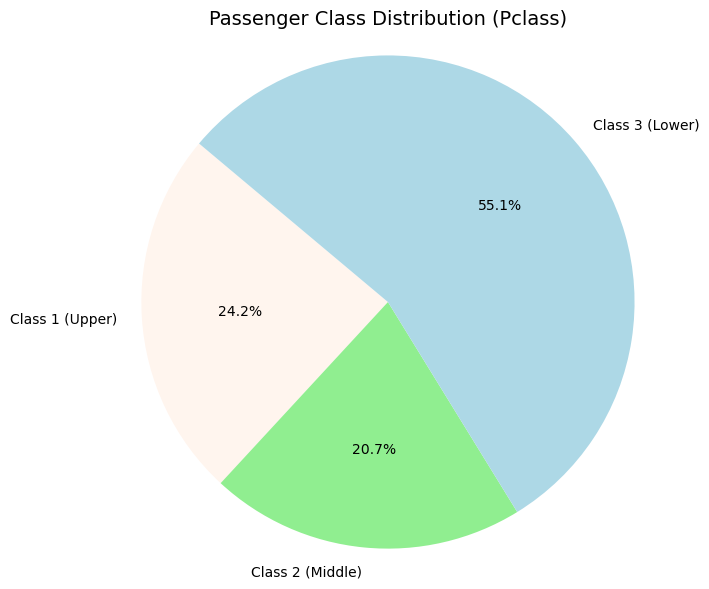

In [17]:
pclass_counts = df['Pclass'].value_counts().sort_index()
print('Passenger Class Counts:')
print(pclass_counts)

labels = ['Class 1 (Upper)', 'Class 2 (Middle)', 'Class 3 (Lower)']
plt.figure(figsize=(7, 7))
plt.pie(pclass_counts, labels=labels, autopct='%1.1f%%',
        startangle=140, colors=['seashell', 'lightgreen', 'lightblue'])
plt.title('Passenger Class Distribution (Pclass)', fontsize=14)
plt.axis('equal')
plt.show()

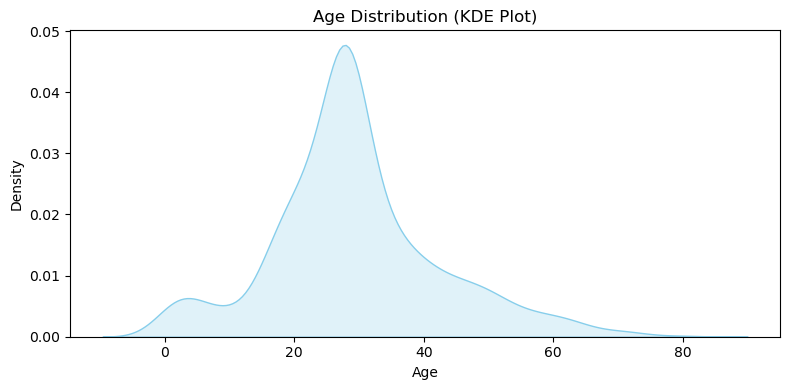

In [18]:
plt.figure(figsize=(8, 4))
sns.kdeplot(df['Age'], fill=True, color='skyblue')
plt.title('Age Distribution (KDE Plot)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

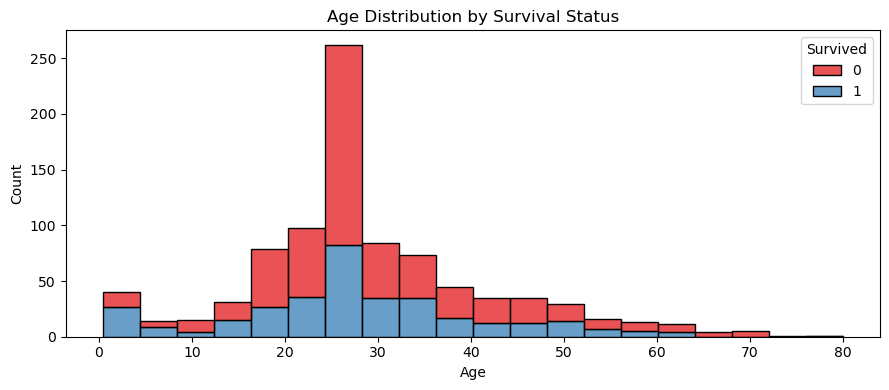

In [19]:
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack',
             bins=20, palette='Set1')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

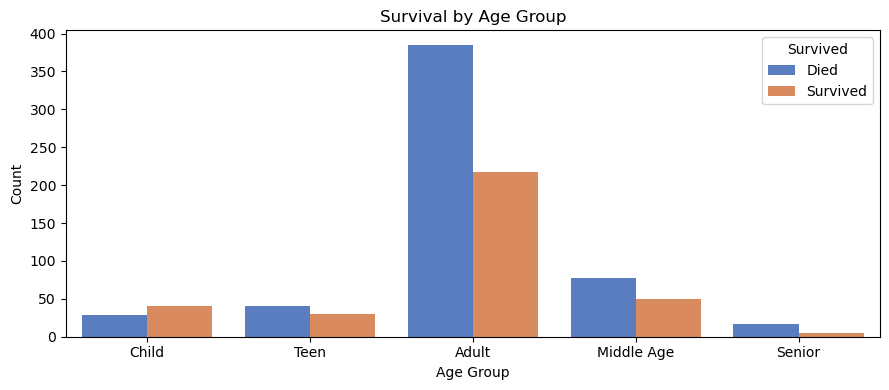

In [20]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 40, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'Middle Age', 'Senior']
)

plt.figure(figsize=(9, 4))
sns.countplot(x='AgeGroup', hue='Survived', data=df, palette='muted')
plt.title('Survival by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['Died', 'Survived'])
plt.tight_layout()
plt.show()

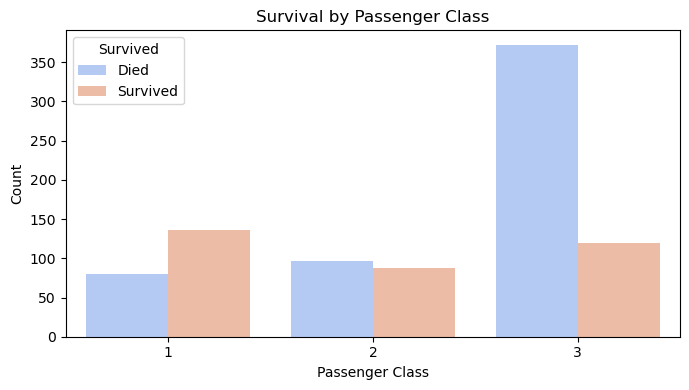

In [21]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='coolwarm')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['Died', 'Survived'])
plt.tight_layout()
plt.show()

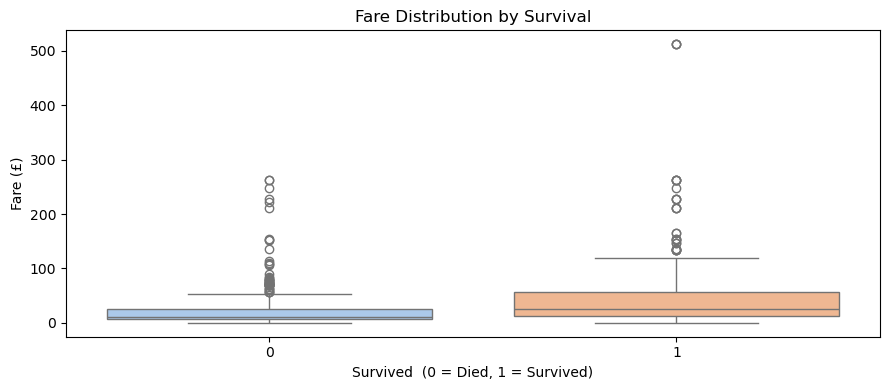

In [22]:
plt.figure(figsize=(9, 4))
sns.boxplot(x='Survived', y='Fare', data=df, palette='pastel')
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived  (0 = Died, 1 = Survived)')
plt.ylabel('Fare (£)')
plt.tight_layout()
plt.show()

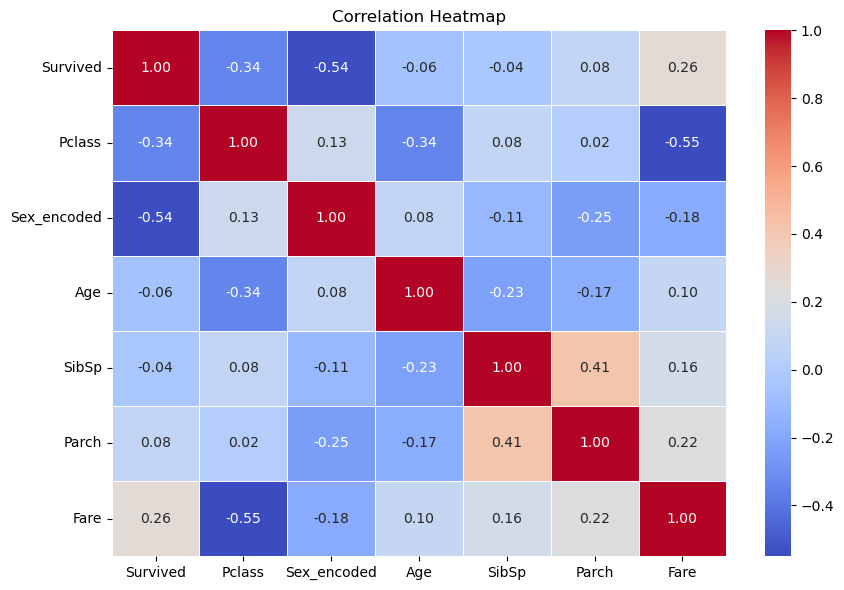

In [23]:
df_corr = df.copy()
df_corr['Sex_encoded'] = (df_corr['Sex'] == 'male').astype(int)
numeric_cols = ['Survived', 'Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare']

plt.figure(figsize=(9, 6))
sns.heatmap(df_corr[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [24]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])           # female=0, male=1
df['Embarked'] = le.fit_transform(df['Embarked']) # C=0, Q=1, S=2

print('Encoding complete. Sample:')
df[['Sex', 'Embarked']].head()

Encoding complete. Sample:


,Sex,Embarked
0,1,2
1,0,0
2,0,2
3,0,2
4,1,2


In [25]:
df_model = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'AgeGroup'])

X = df_model.drop('Survived', axis=1)
y = df_model['Survived']

print('Features (X):', list(X.columns))
print('X shape:', X.shape, '| y shape:', y.shape)

Features (X): ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X shape: (891, 7) | y shape: (891,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 623
Testing  samples : 268


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Scaling complete')

✅ Scaling complete


In [28]:
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print('✅ Model trained successfully')

✅ Model trained successfully


In [29]:
y_pred = log_reg.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f'🎯 Accuracy: {acc:.4f}  ({acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Died (0)', 'Survived (1)']))

🎯 Accuracy: 0.8134  (81.34%)

Classification Report:
              precision    recall  f1-score   support

    Died (0)       0.82      0.87      0.85       157
Survived (1)       0.80      0.73      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



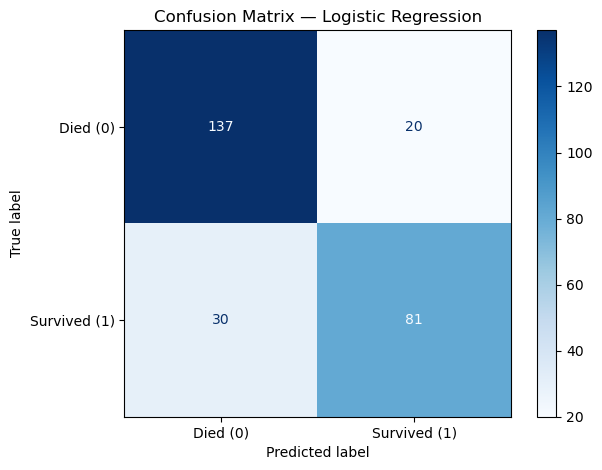

True  Negatives : 137
False Positives : 20
False Negatives : 30
True  Positives : 81


In [30]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Died (0)', 'Survived (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True  Negatives : {tn}')
print(f'False Positives : {fp}')
print(f'False Negatives : {fn}')
print(f'True  Positives : {tp}')

 Feature  Coefficient
    Fare     0.133478
   Parch    -0.082757
Embarked    -0.228806
   SibSp    -0.323025
     Age    -0.423261
  Pclass    -0.745868
     Sex    -1.223858


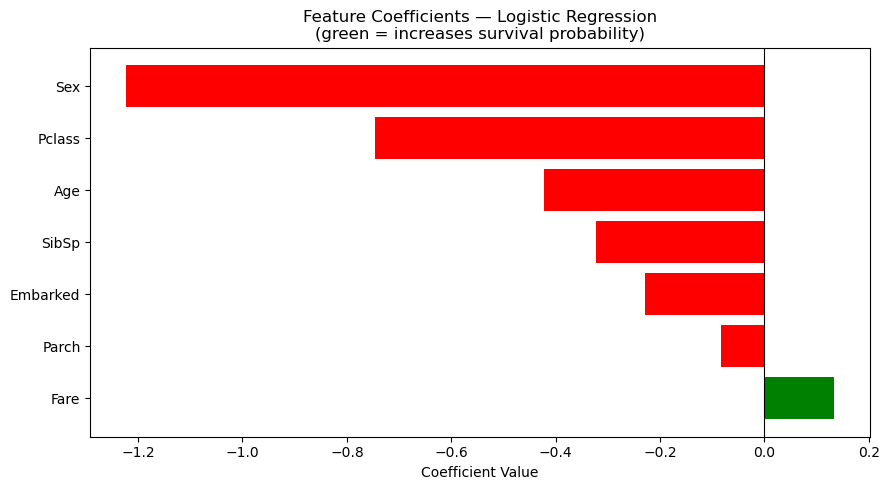

In [31]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

plt.figure(figsize=(9, 5))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Logistic Regression\n(green = increases survival probability)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [33]:
new_passengers = pd.DataFrame([
   
    {'Pclass': 1, 'Sex': 0, 'Age': 29, 'SibSp': 1, 'Parch': 0, 'Fare': 71.28, 'Embarked': 0},

    {'Pclass': 3, 'Sex': 1, 'Age': 22, 'SibSp': 0, 'Parch': 0, 'Fare':  7.25, 'Embarked': 2},
 
    {'Pclass': 2, 'Sex': 0, 'Age': 10, 'SibSp': 1, 'Parch': 2, 'Fare': 27.90, 'Embarked': 2},
], columns=X.columns)

new_scaled = scaler.transform(new_passengers)
predictions = log_reg.predict(new_scaled)
probabilities = log_reg.predict_proba(new_scaled)

for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    result = '✅ Survived' if pred == 1 else '❌ Did not survive'
    print(f'Passenger {i+1}: {result}  |  Died={prob[0]:.2f}, Survived={prob[1]:.2f}')

Passenger 1: ✅ Survived  |  Died=0.06, Survived=0.94
Passenger 2: ❌ Did not survive  |  Died=0.88, Survived=0.12
Passenger 3: ✅ Survived  |  Died=0.18, Survived=0.82
